
# CADERNO DE EXERCICIOS - Analise de Dados com Pandas e Seaborn
 Base de dados: modafina_vendas.csv (loja ficticia de roupas)
# Como usar:
   - Coloque o arquivo modafina_vendas.csv na pasta data.
  - Leia a instrucao de cada celula e escreva seu codigo logo abaixo dela.


In [27]:
# Exercicio 1
# Importe as bibliotecas pandas e seaborn e configure o tema visual dos graficos.
import pandas as pd
import seaborn as sns

In [28]:
# Exercicio 2
# Carregue o arquivo modafina_vendas.csv em um DataFrame
# e mostre as primeiras linhas para conhecer os dados.
df = pd.read_csv(r'.\data\dataset_aula02_exercicio_modafina.csv', parse_dates=['data_venda'])
df.head()

,data_venda,categoria_produto,tamanho,preco,quantidade,estado,forma_pagamento,nota_avaliacao
0,2024-01-01,Calças,G,177.95,1,SP,Boleto,4.1
1,2024-01-01,Camisetas,G,52.12,1,SP,Cartão,4.3
2,2024-01-03,Calças,G,213.45,3,PR,Pix,3.9
3,2024-01-03,Camisetas,M,76.81,1,RJ,Pix,4.9
4,2024-01-03,Acessórios,M,132.39,2,RS,Pix,2.9


In [29]:
# Exercicio 3
# Mostre quantas linhas e quantas colunas a base de dados possui.
df.shape

(700, 8)

In [30]:
# Exercicio 4
# Mostre as informacoes gerais da base: o nome das colunas,
# o tipo de cada uma e a quantidade de valores nao nulos.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   data_venda         700 non-null    datetime64[us]
 1   categoria_produto  700 non-null    str           
 2   tamanho            700 non-null    str           
 3   preco              700 non-null    float64       
 4   quantidade         700 non-null    int64         
 5   estado             700 non-null    str           
 6   forma_pagamento    700 non-null    str           
 7   nota_avaliacao     700 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 55.5 KB


In [31]:
# Exercicio 5
# Crie uma nova coluna chamada faturamento, multiplicando o preco
# pela quantidade de cada venda. Depois, mostre as primeiras linhas.
df['faturamento'] = df['quantidade'] * df['preco']

df.head()

,data_venda,categoria_produto,tamanho,preco,quantidade,estado,forma_pagamento,nota_avaliacao,faturamento
0,2024-01-01,Calças,G,177.95,1,SP,Boleto,4.1,177.95
1,2024-01-01,Camisetas,G,52.12,1,SP,Cartão,4.3,52.12
2,2024-01-03,Calças,G,213.45,3,PR,Pix,3.9,640.35
3,2024-01-03,Camisetas,M,76.81,1,RJ,Pix,4.9,76.81
4,2024-01-03,Acessórios,M,132.39,2,RS,Pix,2.9,264.78


In [32]:
# Exercicio 6
# Calcule o faturamento total da loja (a soma da coluna faturamento).
# Em seguida, exiba esse valor formatado como moeda brasileira,
# no formato R$ 0.000,00 (exemplo: R$ 232.687,92).
total_faturamento = df['faturamento'].sum()
faturamento_corrigido = f'{total_faturamento:,.2f}'.replace(',','x').replace('.',',').replace('x','.')
print(faturamento_corrigido)

232.687,92


In [ ]:
# Exercicio 7
# Descubra quantos pedidos existem de cada categoria de produto.
df['categoria_produto'].value_counts(ascending=True) #ascending >>> do maior para o menor

categoria_produto
Acessórios    101
Calçados      118
Vestidos      137
Calças        153
Camisetas     191
Name: count, dtype: int64

In [43]:
# Exercicio 8
# Descubra quanto cada categoria de produto faturou no total,
# ordenando da que mais faturou para a que menos faturou. 
# *** CONVERTER_REAL foi uma função criada para converter automaticamente, sem precisar usar replace

df.groupby(['categoria_produto'],)['faturamento'].sum().sort_values(ascending=True).map(converter_real).reset_index()

,categoria_produto,faturamento
0,Acessórios,"17.504,51"
1,Camisetas,"31.637,03"
2,Calças,"51.954,17"
3,Vestidos,"63.743,92"
4,Calçados,"67.848,29"


Text(0, 0.5, 'Quantidade')

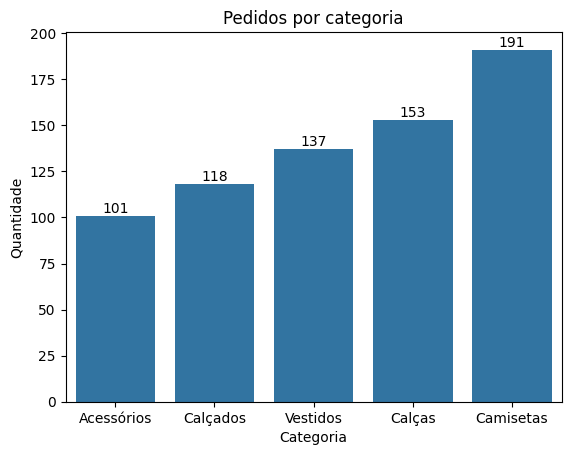

In [56]:
# Exercicio 9
# Crie um grafico que mostre a quantidade de pedidos por categoria de produto.
# Coloque um titulo no grafico e nomes nos eixos.
grafico = sns.countplot(data=df, x='categoria_produto', order=df['categoria_produto'].value_counts(ascending=True).index)
grafico.bar_label(grafico.containers[0])
grafico.set_title('Pedidos por categoria')
grafico.set_xlabel('Categoria')
grafico.set_ylabel('Quantidade')

Text(0, 0.5, 'Preços')

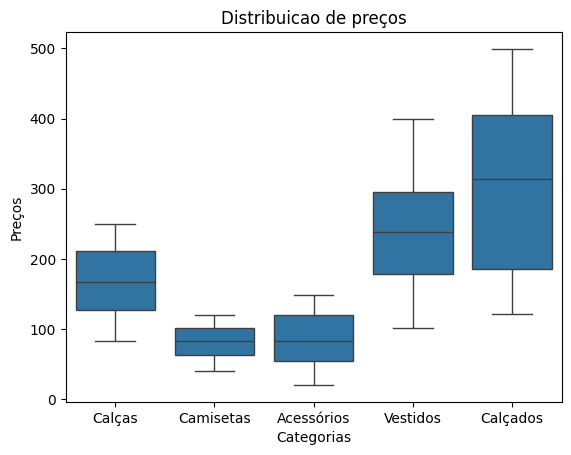

In [36]:
# Exercicio 10
# Crie um grafico que compare a distribuicao do preco entre as
# diferentes categorias de produto. Coloque um titulo no grafico.
grafico = sns.boxplot(data=df, x='categoria_produto', y='preco')
grafico.set_title('Distribuicao de preços')
grafico.set_xlabel('Categorias')
grafico.set_ylabel('Preços')

Text(0, 0.5, 'Preços')

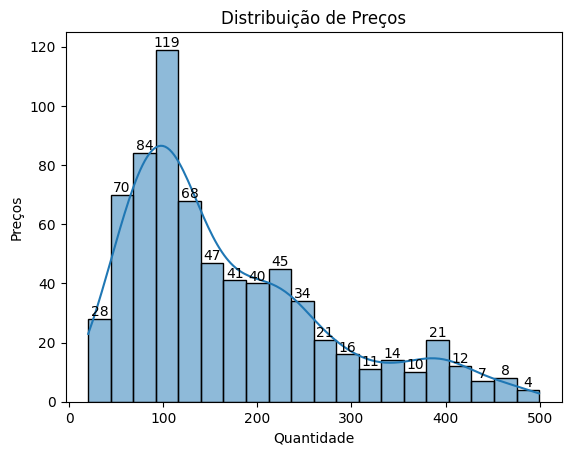

In [57]:
# Exercicio 11
# Crie um grafico que mostre a distribuicao dos precos dos produtos.
# Coloque um titulo no grafico.
grafico = sns.histplot(data=df, x='preco', bins=20, kde=True)
grafico.bar_label(grafico.containers[0])
grafico.set_title('Distribuição de Preços')
grafico.set_xlabel('Quantidade')
grafico.set_ylabel('Preços')

In [ ]:
## Função criada para converter em R$ (. e ,) usada junto com Map

def converter_real(valor):
    return(f'{valor:,.2f}').replace(',','x').replace('.',',').replace('x','.')

In [ ]:
print('Finalizando primeira semana...')